In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cmocean
from sklearn.cluster import KMeans

In [3]:
df_267 = pd.read_csv("bouguer_erg_267.txt",
                     sep=r"\s+",
                     header=None,
                     names=["longitude", "latitude", "bouguer_267"])

df_290 = pd.read_csv("bouguer_erg_290.txt",
                     sep=r"\s+",
                     header=None,
                     names=["longitude", "latitude", "bouguer_290"])

df_topo = pd.read_csv("topo_erg.txt",
                      sep=r"\s+",
                      header=None,
                      names=["longitude", "latitude", "elevation"])

In [4]:
df = pd.DataFrame({
    "longitude"  : df_267["longitude"],
    "latitude"   : df_267["latitude"],
    "bouguer_267": df_267["bouguer_267"],
    "bouguer_290": df_290["bouguer_290"],
    "elevation"  : df_topo["elevation"]
})

df_ocean = df[df["elevation"] < -200].reset_index(drop=True)

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_ocean["cluster"] = kmeans.fit_predict(df_ocean[["longitude", "latitude", "bouguer_267", "bouguer_290"]])

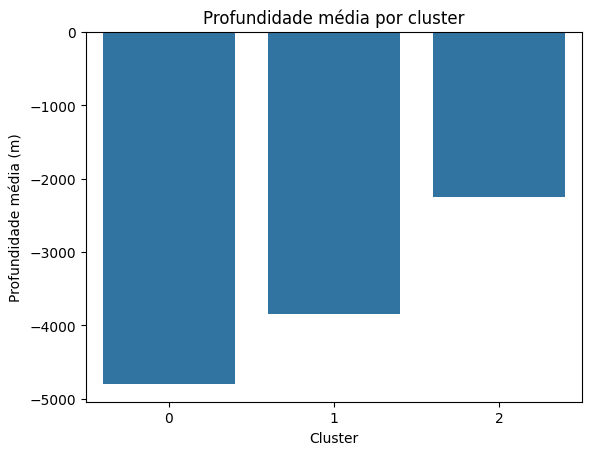

In [6]:
media_elevation = df_ocean.groupby("cluster")["elevation"].mean()
sns.barplot(x=media_elevation.index, y=media_elevation.values)
plt.xlabel("Cluster")
plt.ylabel("Profundidade média (m)")
plt.title("Profundidade média por cluster")
plt.show()